# Thesis Plots — Part 1: Core Results & Model Failure Analysis

**Plot 1a** — Overall QUR by Dataset × Configuration  
**Plot 1b** — QUR by Corruption Complexity (C1/C2/C3)  
**Plot 2a** — QUR by NLP Entity Type (radar)  
**Plot 2b** — QUR by Document Element Type (horizontal bar)

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Paths ───────────────────────────────────────────────────
RESULTS_DIR = "/home/amartinelli/VRD-UQA/artifacts/evaluation_runs/latest"
RESULTS_DIR = "/home/amartinelli/VRD-UQA/artifacts/presentations/gemma4_all_val_300"
OUTPUT_DIR  = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASETS = ["DUDE", "MPDocVQA", "SlideVQA", "BDocs"]
DATASET_LABELS = {"DUDE": "DUDE", "MPDocVQA": "MPDocVQA", "SlideVQA": "SlideVQA", "BDocs": "BoundingDocs"}

import json, glob

def discover_configs(dataset):
    """Return {config_slug: label} for a dataset by reading leaf manifests."""
    out = {}
    for man_path in sorted(glob.glob(os.path.join(RESULTS_DIR, dataset, "*", "manifest.json"))):
        with open(man_path) as f:
            man = json.load(f)
        out[man["config"]] = man.get("label", man["config"])
    return out

# Union of configs across datasets, stable first-seen order.
CONFIGS, CONFIG_LABELS = [], {}
for _ds in DATASETS:
    for _slug, _lab in discover_configs(_ds).items():
        if _slug not in CONFIG_LABELS:
            CONFIGS.append(_slug)
            CONFIG_LABELS[_slug] = _lab

# Enforce display order: zeroshot → fewshot → finetuned
_ORDER = {"zeroshot": 0, "fewshot": 1, "finetuned": 2}
CONFIGS.sort(key=lambda c: next((v for k, v in _ORDER.items() if c.startswith(k)), 99))

# Color per config (stable assignment onto a palette).
_PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
COLORS = {c: _PALETTE[i % len(_PALETTE)] for i, c in enumerate(CONFIGS)}

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.linestyle": "--", "grid.alpha": 0.5,
})

def load_csv(dataset, config, filename):
    """Load a results CSV from <dataset>/<config>/metrics/<filename>."""
    path = os.path.join(RESULTS_DIR, dataset, config, "metrics", filename)
    if not os.path.exists(path):
        print(f"[MISSING] {path}")
        return None
    df = pd.read_csv(path, index_col=0)
    df.columns = ["value"]
    return df["value"]

def safe_get(df, dataset, config, col):
    """Return df[col] for a (dataset, config) row, or NaN if the combination is absent."""
    rows = df.loc[(df.dataset == dataset) & (df.config == config), col]
    return rows.values[0] if len(rows) > 0 else np.nan


## Load QUR data

In [22]:
records = []
for dataset in DATASETS:
    for config in CONFIGS:
        s = load_csv(dataset, config, "QUR.csv")
        if s is None:
            continue
        # QUR_C3 = 0.0 means no C3 questions exist in this split → treat as NaN
        c3_val = s.get("QUR_C3", np.nan)
        if c3_val == 0.0:
            c3_val = np.nan
        records.append({
            "dataset": dataset,
            "config":  config,
            "QUR":     s.get("QUR",    np.nan),
            "QUR_C1":  s.get("QUR_C1", np.nan),
            "QUR_C2":  s.get("QUR_C2", np.nan),
            "QUR_C3":  c3_val,
        })

qur_df = pd.DataFrame(records)
qur_df

,dataset,config,QUR,QUR_C1,QUR_C2,QUR_C3
0,DUDE,zeroshot_ocr,0.620000,0.605505,0.675676,0.500000
1,DUDE,fewshot_ocr_k2_mixed_random,0.766667,0.738532,0.837838,0.875000
2,DUDE,finetuned_ocr,0.853333,0.830275,0.918919,0.875000
3,MPDocVQA,zeroshot_ocr,0.566667,0.531532,0.656716,0.727273
4,MPDocVQA,fewshot_ocr_k2_mixed_random,0.626667,0.572072,0.791045,0.727273
5,MPDocVQA,finetuned_ocr,0.800000,0.752252,0.925373,1.000000
6,SlideVQA,zeroshot_ocr,0.466667,0.404145,0.550725,0.631579
7,SlideVQA,fewshot_ocr_k2_mixed_random,0.520000,0.466321,0.594203,0.657895
8,SlideVQA,finetuned_ocr,0.590000,0.512953,0.739130,0.710526
9,BDocs,zeroshot_ocr,0.570000,0.514523,0.796610,NaN


## Plot 1a — Overall QUR by Dataset × Configuration

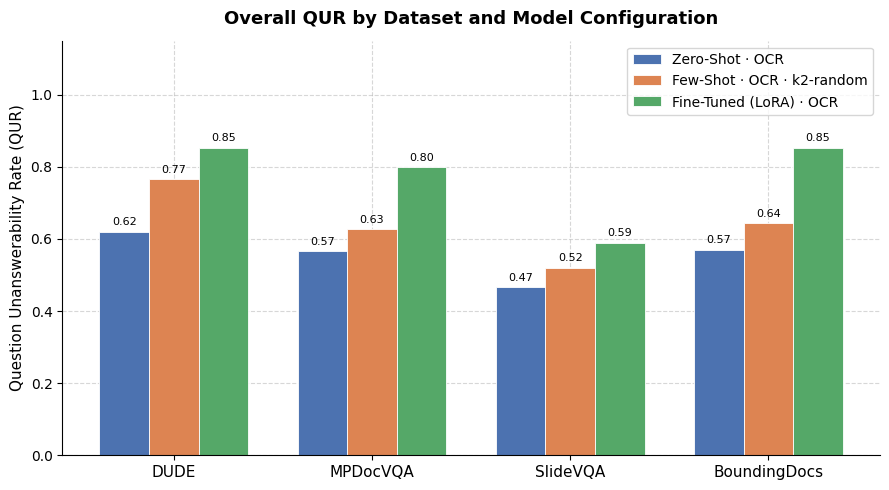

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

bar_width = 0.25
x = np.arange(len(DATASETS))

for i, config in enumerate(CONFIGS):
    vals = [safe_get(qur_df, d, config, "QUR") for d in DATASETS]
    plot_vals = [v if not np.isnan(v) else 0 for v in vals]
    bars = ax.bar(x + i * bar_width, plot_vals, width=bar_width,
                  color=COLORS[config], label=CONFIG_LABELS[config],
                  edgecolor="white", linewidth=0.6)
    for bar, val in zip(bars, vals):
        if np.isnan(val):
            bar.set_hatch("///")
            bar.set_facecolor("#dddddd")
            bar.set_edgecolor("#aaaaaa")
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.012,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + bar_width)
ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS], fontsize=11)
ax.set_ylabel("Question Unanswerability Rate (QUR)", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title("Overall QUR by Dataset and Model Configuration",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10, framealpha=0.8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot1a_qur_overall.pdf"), bbox_inches="tight")
plt.show()


## Plot 1b — QUR by Corruption Complexity Level (C1 / C2 / C3)

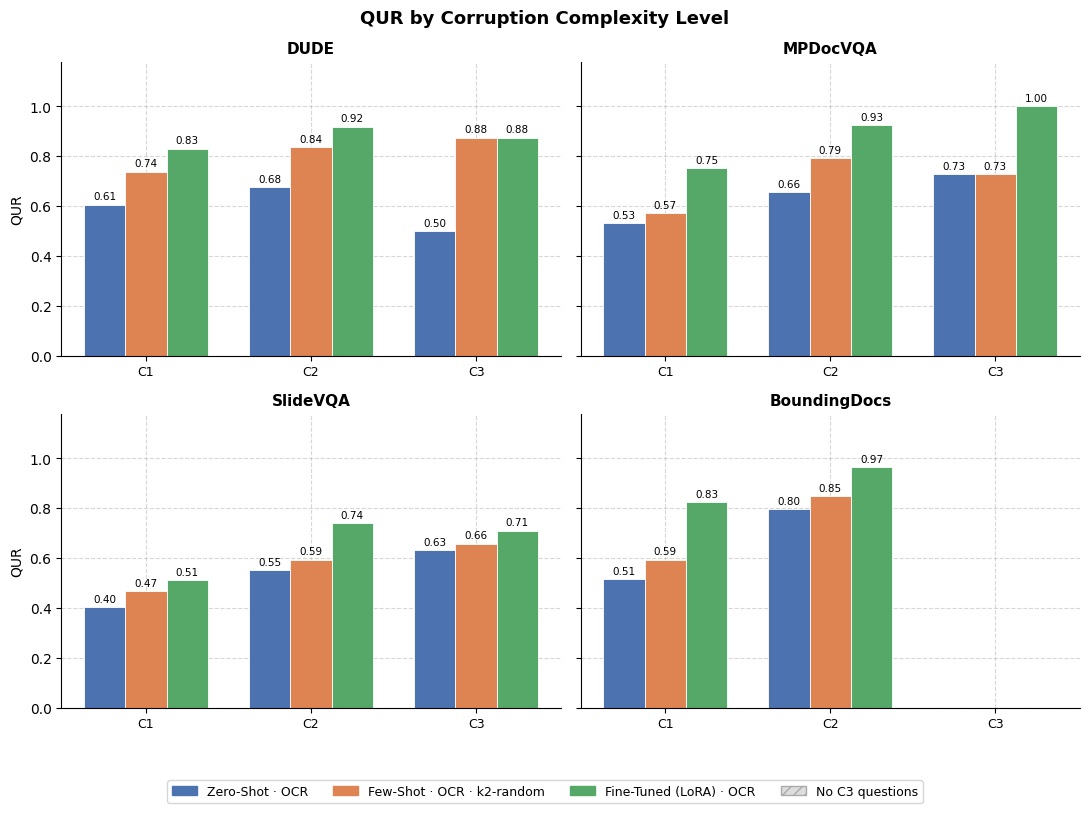

In [24]:
COMPLEXITY_COLS   = ["QUR_C1", "QUR_C2", "QUR_C3"]
COMPLEXITY_LABELS = ["C1", "C2", "C3"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
axes = axes.flatten()

bar_width = 0.25
x = np.arange(len(COMPLEXITY_COLS))

for idx, dataset in enumerate(DATASETS):
    ax = axes[idx]
    for i, config in enumerate(CONFIGS):
        row = qur_df[(qur_df.dataset == dataset) & (qur_df.config == config)]
        if row.empty:
            continue
        vals = [row[c].values[0] for c in COMPLEXITY_COLS]
        # Skip NaN bars gracefully
        plot_vals = [v if not np.isnan(v) else 0 for v in vals]
        bars = ax.bar(x + i * bar_width, plot_vals, width=bar_width,
                      color=COLORS[config], label=CONFIG_LABELS[config],
                      edgecolor="white", linewidth=0.6)
        # Hatch NaN bars to signal missing data
        for bar, val in zip(bars, vals):
            if np.isnan(val):
                bar.set_hatch("///")
                bar.set_edgecolor("#aaaaaa")
                bar.set_facecolor("#dddddd")
            else:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.012,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_title(DATASET_LABELS[dataset], fontsize=11, fontweight="bold")
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(COMPLEXITY_LABELS, fontsize=9)
    ax.set_ylim(0, 1.18)
    if idx % 2 == 0:
        ax.set_ylabel("QUR", fontsize=10)

handles = [mpatches.Patch(color=COLORS[c], label=CONFIG_LABELS[c]) for c in CONFIGS]
na_patch = mpatches.Patch(facecolor="#dddddd", edgecolor="#aaaaaa",
                           hatch="///", label="No C3 questions")
fig.legend(handles=handles + [na_patch], loc="lower center",
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("QUR by Corruption Complexity Level",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "plot1b_qur_complexity.pdf"), bbox_inches="tight")
plt.show()

## Load NLP Entity (NLPE) data

In [25]:
ENTITY_TYPES = ["NUMERIC", "TEMPORAL", "ENTITY", "LOCATION", "STRUCTURE"]

nlpe_records = []
for dataset in DATASETS:
    for config in CONFIGS:
        s = load_csv(dataset, config, "QUR_NLPE.csv")
        if s is None:
            continue
        for etype in ENTITY_TYPES:
            nlpe_records.append({
                "dataset":     dataset,
                "config":      config,
                "entity_type": etype,
                "QUR":         s.get(etype, np.nan),
            })

nlpe_df = pd.DataFrame(nlpe_records)
nlpe_df.pivot_table(index=["dataset", "config"], columns="entity_type", values="QUR")

entity_type                             ENTITY  LOCATION   NUMERIC  STRUCTURE  \
dataset  config                                                                 
BDocs    fewshot_ocr_k2_mixed_random  0.680000  0.651515  0.769231   0.606383   
         finetuned_ocr                0.880000  0.909091  0.910256   0.872340   
         zeroshot_ocr                 0.586667  0.560606  0.743590   0.553191   
DUDE     fewshot_ocr_k2_mixed_random  0.817259  0.810345  0.857143   0.720000   
         finetuned_ocr                0.878173  0.862069  1.000000   0.840000   
         zeroshot_ocr                 0.715736  0.534483  0.714286   0.520000   
MPDocVQA fewshot_ocr_k2_mixed_random  0.654545  0.677419  0.647059   0.639640   
         finetuned_ocr                0.800000  0.838710  0.823529   0.837838   
         zeroshot_ocr                 0.624242  0.419355  0.500000   0.594595   
SlideVQA fewshot_ocr_k2_mixed_random  0.633333  0.362963  0.650000   0.450000   
         finetuned_ocr                0.705556  0.511111  0.687500   0.450000   
         zeroshot_ocr                 0.650000  0.325926  0.562500   0.300000   

entity_type                           TEMPORAL  
dataset  config                                 
BDocs    fewshot_ocr_k2_mixed_random  0.695652  
         finetuned_ocr                0.739130  
         zeroshot_ocr                 0.586957  
DUDE     fewshot_ocr_k2_mixed_random  0.666667  
         finetuned_ocr                1.000000  
         zeroshot_ocr                 0.666667  
MPDocVQA fewshot_ocr_k2_mixed_random  0.729167  
         finetuned_ocr                0.937500  
         zeroshot_ocr                 0.645833  
SlideVQA fewshot_ocr_k2_mixed_random  0.766667  
         finetuned_ocr                0.733333  
         zeroshot_ocr                 0.466667

## Plot 2a — QUR by NLP Entity Type (Radar / Spider Chart)

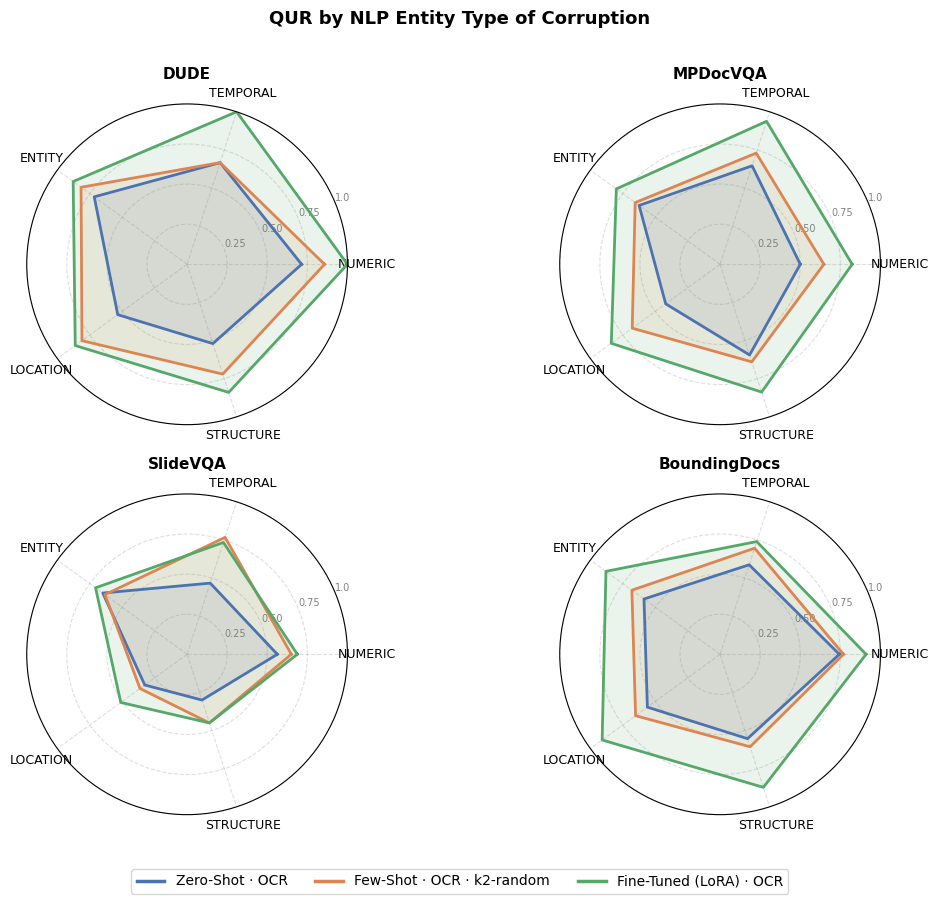

In [26]:
N      = len(ENTITY_TYPES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, axes = plt.subplots(2, 2, figsize=(11, 9),
                         subplot_kw={"projection": "polar"})
axes = axes.flatten()

for idx, dataset in enumerate(DATASETS):
    ax = axes[idx]

    for config in CONFIGS:
        sub = nlpe_df[(nlpe_df.dataset == dataset) & (nlpe_df.config == config)]
        if sub.empty:
            continue
        vals = [sub.loc[sub.entity_type == et, "QUR"].values[0]
                if et in sub.entity_type.values else 0
                for et in ENTITY_TYPES]
        vals += vals[:1]
        ax.plot(angles, vals,
                color=COLORS[config], linewidth=2,
                label=CONFIG_LABELS[config])
        ax.fill(angles, vals, color=COLORS[config], alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(ENTITY_TYPES, fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], fontsize=7, color="grey")
    ax.set_title(DATASET_LABELS[dataset], fontsize=11,
                 fontweight="bold", pad=18)
    ax.grid(True, linestyle="--", alpha=0.4)

handles = [Line2D([0], [0], color=COLORS[c], linewidth=2.5,
                  label=CONFIG_LABELS[c]) for c in CONFIGS]
fig.legend(handles=handles, loc="lower center",
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("QUR by NLP Entity Type of Corruption",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, "plot2a_qur_nlpe_radar.pdf"), bbox_inches="tight")
plt.show()

## Load Document Element (DE) data

In [27]:
# Canonical element name → display label
DE_RENAME = {
    "title":            "Title",
    "plain text":       "Plain Text",
    "figure":           "Figure",
    "figure_caption":   "Fig. Caption",
    "table":            "Table",
    "table_caption":    "Table Caption",
    "table_footnote":   "Table Footnote",
    "abandon":          "Abandon",
    "isolate_formula":  "Formula",
    "formula_caption":  "Formula Caption",
}

de_records = []
for dataset in DATASETS:
    for config in CONFIGS:
        s = load_csv(dataset, config, "QUR_DE.csv")
        if s is None:
            continue
        for elem, val in s.items():
            if val > 0:   # 0.0 means the element type is absent in this dataset
                de_records.append({
                    "dataset": dataset,
                    "config":  config,
                    "element": DE_RENAME.get(elem, elem),
                    "QUR":     val,
                })

de_df = pd.DataFrame(de_records)

# Keep only elements that appear in at least 2 datasets (avoids singleton noise)
counts = de_df.groupby("element")["dataset"].nunique()
common_elements = counts[counts >= 2].index.tolist()
de_df = de_df[de_df.element.isin(common_elements)]

print("Element types retained:", sorted(de_df.element.unique()))

Element types retained: ['Abandon', 'Figure', 'Plain Text', 'Table', 'Table Footnote', 'Title']


## Plot 2b — QUR by Document Element Type (Horizontal Bar)

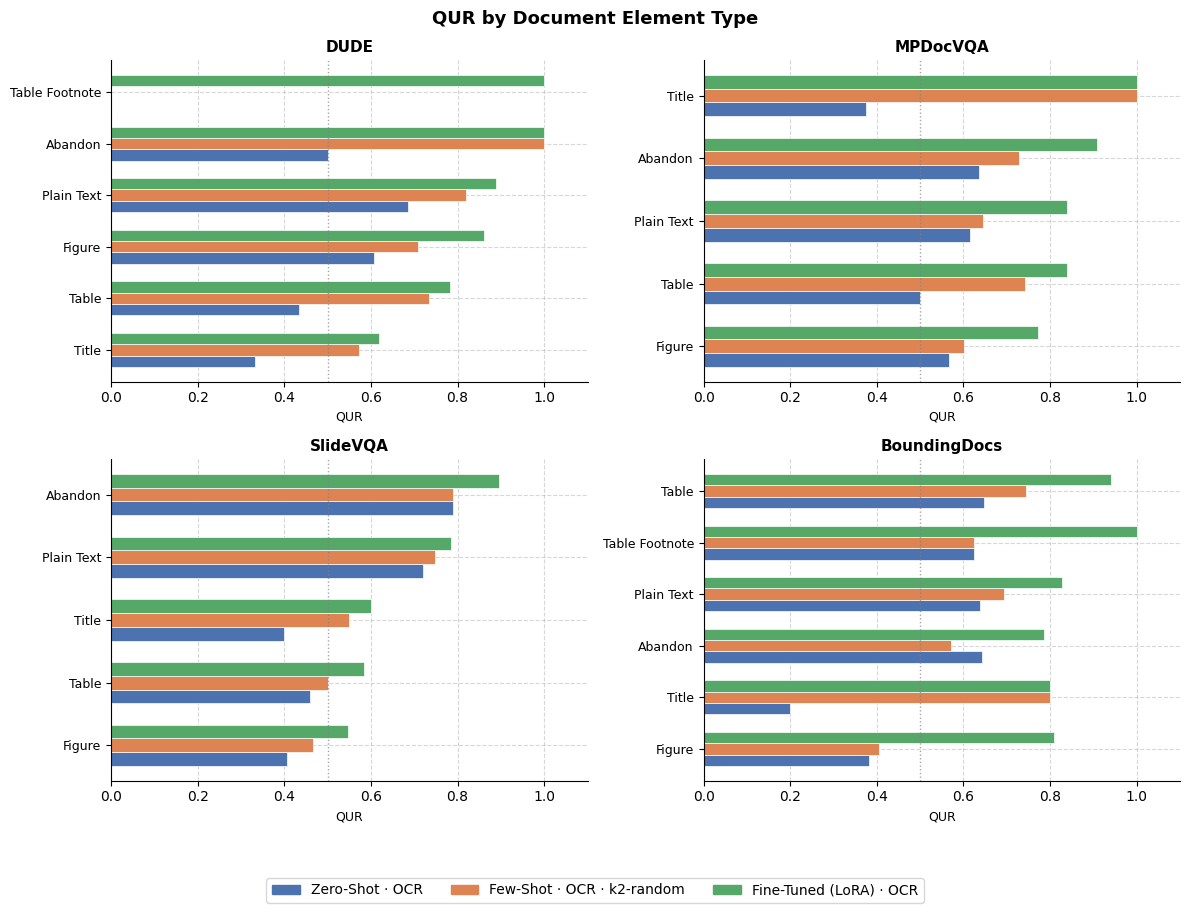

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for idx, dataset in enumerate(DATASETS):
    ax = axes[idx]
    sub = de_df[de_df.dataset == dataset]
    if sub.empty:
        ax.set_visible(False)
        continue

    # Sort elements by average QUR (ascending → hardest at bottom)
    elem_order = (sub.groupby("element")["QUR"]
                    .mean()
                    .sort_values(ascending=True)
                    .index.tolist())

    n_elems  = len(elem_order)
    n_cfgs   = len(CONFIGS)
    bar_h    = 0.22
    y_base   = np.arange(n_elems)

    for i, config in enumerate(CONFIGS):
        csub = sub[sub.config == config].set_index("element")
        vals = [csub.loc[e, "QUR"] if e in csub.index else np.nan
                for e in elem_order]
        ax.barh(y_base + i * bar_h, vals, height=bar_h,
                color=COLORS[config], label=CONFIG_LABELS[config],
                edgecolor="white", linewidth=0.5)

    ax.set_yticks(y_base + bar_h)
    ax.set_yticklabels(elem_order, fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel("QUR", fontsize=9)
    ax.set_title(DATASET_LABELS[dataset], fontsize=11, fontweight="bold")
    ax.axvline(0.5, color="grey", linestyle=":", linewidth=1, alpha=0.7)

handles = [mpatches.Patch(color=COLORS[c], label=CONFIG_LABELS[c]) for c in CONFIGS]
fig.legend(handles=handles, loc="lower center",
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("QUR by Document Element Type",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "plot2b_qur_de_horizontal.pdf"), bbox_inches="tight")
plt.show()

## Plot 3 — Spatial & Structural Analysis

### Plot 3a — QUR by Page Quadrant

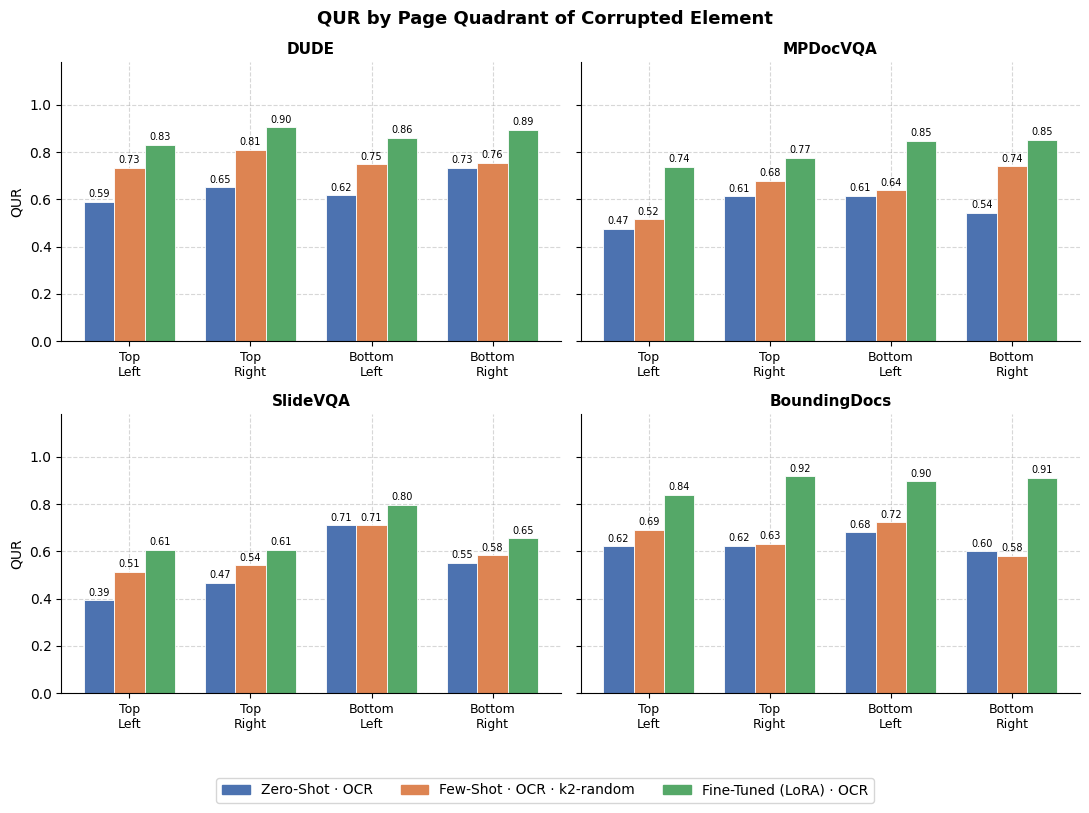

In [29]:
QUADRANTS   = ["TOP_LEFT", "TOP_RIGHT", "BOTTOM_LEFT", "BOTTOM_RIGHT"]
QUAD_LABELS = ["Top\nLeft", "Top\nRight", "Bottom\nLeft", "Bottom\nRight"]

qp_records = []
for dataset in DATASETS:
    for config in CONFIGS:
        s = load_csv(dataset, config, "QUR_QP.csv")
        if s is None:
            continue
        for q in QUADRANTS:
            qp_records.append({"dataset": dataset, "config": config,
                                "quadrant": q, "QUR": s.get(q, np.nan)})
qp_df = pd.DataFrame(qp_records)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
axes = axes.flatten()
bar_width = 0.25
x = np.arange(len(QUADRANTS))

for idx, dataset in enumerate(DATASETS):
    ax = axes[idx]
    for i, config in enumerate(CONFIGS):
        sub = qp_df[(qp_df.dataset == dataset) & (qp_df.config == config)]
        vals = [sub.loc[sub.quadrant == q, "QUR"].values[0]
                if not sub.empty and q in sub.quadrant.values else np.nan
                for q in QUADRANTS]
        bars = ax.bar(x + i * bar_width, vals, width=bar_width,
                      color=COLORS[config], label=CONFIG_LABELS[config],
                      edgecolor="white", linewidth=0.6)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.012,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(QUAD_LABELS, fontsize=9)
    ax.set_ylim(0, 1.18)
    ax.set_title(DATASET_LABELS[dataset], fontsize=11, fontweight="bold")
    if idx % 2 == 0:
        ax.set_ylabel("QUR", fontsize=10)

handles = [mpatches.Patch(color=COLORS[c], label=CONFIG_LABELS[c]) for c in CONFIGS]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("QUR by Page Quadrant of Corrupted Element",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "plot3a_qur_quadrant.pdf"), bbox_inches="tight")
plt.show()

### Plot 3b — Unanswerability Rate: In-Page vs Out-Page

Is the model refusing for the right reason?
- In-page (solid bar): the page shown contains the location of the original (non-corrupted) answer. The model has the relevant visual content in front of it.
- Out-page (hatched bar): the page shown does not contain the original answer. The relevant information lives elsewhere in the document.

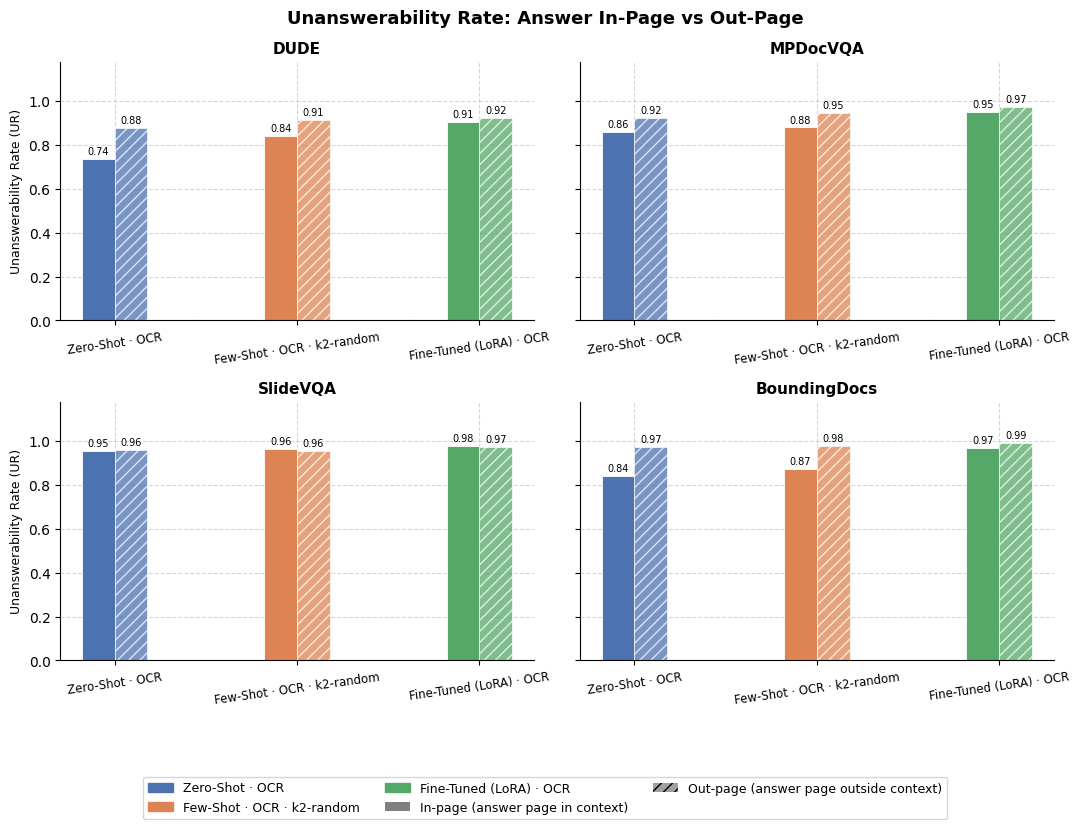

In [30]:
ur_records = []
for dataset in DATASETS:
    for config in CONFIGS:
        s_in  = load_csv(dataset, config, "UR_PAGE_inpage.csv")
        s_out = load_csv(dataset, config, "UR_PAGE_outpage.csv")
        if s_in is None or s_out is None:
            continue
        ur_records.append({
            "dataset":  dataset, "config": config,
            "UR_inpage":  s_in.get("UR_inpage",  np.nan),
            "UR_outpage": s_out.get("UR_outpage", np.nan),
        })
ur_df = pd.DataFrame(ur_records)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
axes = axes.flatten()
bar_width = 0.18
x = np.arange(len(CONFIGS))

for idx, dataset in enumerate(DATASETS):
    ax = axes[idx]
    sub = ur_df[ur_df.dataset == dataset]
    for i, config in enumerate(CONFIGS):
        row = sub[sub.config == config]
        if row.empty:
            continue
        in_val  = row["UR_inpage"].values[0]
        out_val = row["UR_outpage"].values[0]
        ax.bar(i - bar_width / 2, in_val,  width=bar_width,
               color=COLORS[config], edgecolor="white", linewidth=0.6)
        ax.bar(i + bar_width / 2, out_val, width=bar_width,
               color=COLORS[config], hatch="///",
               edgecolor="white", linewidth=0.6, alpha=0.75)
        for pos, val in [(i - bar_width / 2, in_val), (i + bar_width / 2, out_val)]:
            ax.text(pos, val + 0.012, f"{val:.2f}", ha="center",
                    va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], fontsize=8.5, rotation=8)
    ax.set_ylim(0, 1.18)
    ax.set_title(DATASET_LABELS[dataset], fontsize=11, fontweight="bold")
    if idx % 2 == 0:
        ax.set_ylabel("Unanswerability Rate (UR)", fontsize=9)

solid_patch  = mpatches.Patch(facecolor="grey",   label="In-page (answer page in context)")
hatch_patch  = mpatches.Patch(facecolor="grey", hatch="///", alpha=0.75,
                               label="Out-page (answer page outside context)")
config_handles = [mpatches.Patch(color=COLORS[c], label=CONFIG_LABELS[c]) for c in CONFIGS]
fig.legend(handles=config_handles + [solid_patch, hatch_patch],
           loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Unanswerability Rate: Answer In-Page vs Out-Page",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.09, 1, 1])
# plt.savefig(os.path.join(OUTPUT_DIR, "plot3b_ur_inpage_outpage.pdf"), bbox_inches="tight")
plt.show()

## Plot 4 — Document Complexity Effects

### QUR by Visual Element Density

Do corruptions on visually cluttered pages get caught less often?

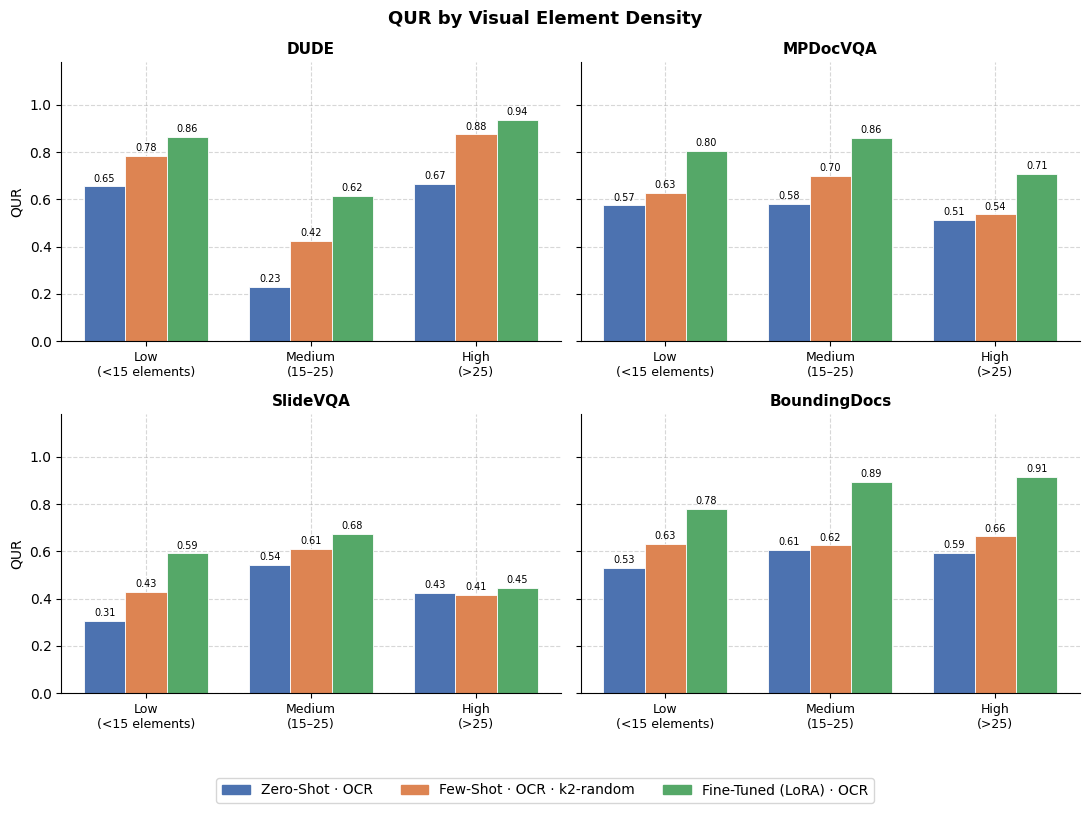

In [31]:
DED_BINS   = ["<15", "15-25", ">25"]
DED_LABELS = ["Low\n(<15 elements)", "Medium\n(15–25)", "High\n(>25)"]

ded_records = []
for dataset in DATASETS:
    for config in CONFIGS:
        s = load_csv(dataset, config, "QUR_DED.csv")
        if s is None:
            continue
        for b in DED_BINS:
            ded_records.append({"dataset": dataset, "config": config,
                                 "bin": b, "QUR": s.get(b, np.nan)})
ded_df = pd.DataFrame(ded_records)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
axes = axes.flatten()
bar_width = 0.25
x = np.arange(len(DED_BINS))

for idx, dataset in enumerate(DATASETS):
    ax = axes[idx]
    for i, config in enumerate(CONFIGS):
        sub = ded_df[(ded_df.dataset == dataset) & (ded_df.config == config)].set_index("bin")
        vals = [sub.loc[b, "QUR"] if b in sub.index else np.nan for b in DED_BINS]
        bars = ax.bar(x + i * bar_width, vals, width=bar_width,
                      color=COLORS[config], label=CONFIG_LABELS[config],
                      edgecolor="white", linewidth=0.6)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.012,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(DED_LABELS, fontsize=9)
    ax.set_ylim(0, 1.18)
    ax.set_title(DATASET_LABELS[dataset], fontsize=11, fontweight="bold")
    if idx % 2 == 0:
        ax.set_ylabel("QUR", fontsize=10)

handles = [mpatches.Patch(color=COLORS[c], label=CONFIG_LABELS[c]) for c in CONFIGS]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("QUR by Visual Element Density",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "plot4b_qur_density.pdf"), bbox_inches="tight")
plt.show()

## Plot 5 — Synthesis

### Plot 5a — Improvement Delta Heatmap (Fine-Tuned vs Zero-Shot)

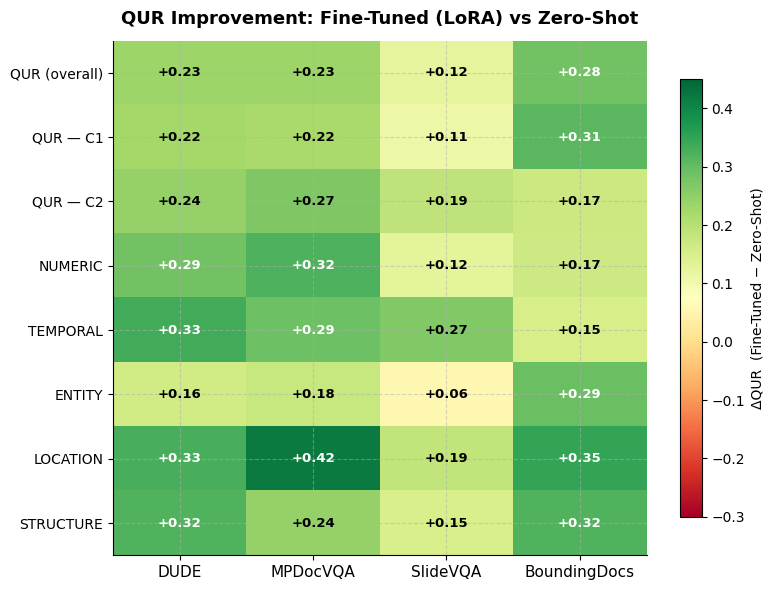

In [32]:
DELTA_METRICS = {
    "QUR (overall)": ("QUR.csv",      "QUR"),
    "QUR — C1":      ("QUR.csv",      "QUR_C1"),
    "QUR — C2":      ("QUR.csv",      "QUR_C2"),
    "NUMERIC":       ("QUR_NLPE.csv", "NUMERIC"),
    "TEMPORAL":      ("QUR_NLPE.csv", "TEMPORAL"),
    "ENTITY":        ("QUR_NLPE.csv", "ENTITY"),
    "LOCATION":      ("QUR_NLPE.csv", "LOCATION"),
    "STRUCTURE":     ("QUR_NLPE.csv", "STRUCTURE"),
}

delta_data = {}
_FT = next((c for c in CONFIGS if c.startswith("finetuned")), None)
_ZS = next((c for c in CONFIGS if c.startswith("zeroshot")), None)
for metric_label, (csv_file, row_key) in DELTA_METRICS.items():
    row = {}
    for dataset in DATASETS:
        s_ft = load_csv(dataset, _FT, csv_file) if _FT else None
        s_zs = load_csv(dataset, _ZS, csv_file) if _ZS else None
        if s_ft is None or s_zs is None:
            row[DATASET_LABELS[dataset]] = np.nan
        else:
            ft_val = s_ft.get(row_key, np.nan)
            zs_val = s_zs.get(row_key, np.nan)
            if np.isnan(ft_val) or np.isnan(zs_val):
                row[DATASET_LABELS[dataset]] = np.nan
            else:
                row[DATASET_LABELS[dataset]] = ft_val - zs_val
    delta_data[metric_label] = row

delta_df = pd.DataFrame(delta_data).T

fig, ax = plt.subplots(figsize=(8, 6))
vals = delta_df.values.astype(float)
im = ax.imshow(vals, cmap="RdYlGn", vmin=-0.3, vmax=0.45, aspect="auto")

ax.set_xticks(range(len(delta_df.columns)))
ax.set_xticklabels(delta_df.columns, fontsize=11)
ax.set_yticks(range(len(delta_df.index)))
ax.set_yticklabels(delta_df.index, fontsize=10)
ax.set_title("QUR Improvement: Fine-Tuned (LoRA) vs Zero-Shot",
             fontsize=13, fontweight="bold", pad=12)

for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        v = vals[i, j]
        if not np.isnan(v):
            text_color = "white" if abs(v) > 0.28 else "black"
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                    fontsize=9.5, color=text_color, fontweight="bold")
        else:
            ax.text(j, i, "N/A", ha="center", va="center",
                    fontsize=8, color="#888888")

plt.colorbar(im, ax=ax, label="ΔQUR  (Fine-Tuned − Zero-Shot)", shrink=0.85)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot5a_delta_heatmap.pdf"), bbox_inches="tight")
plt.show()

### Plot 5b — UR vs QUR Scatter (Refusal Precision)

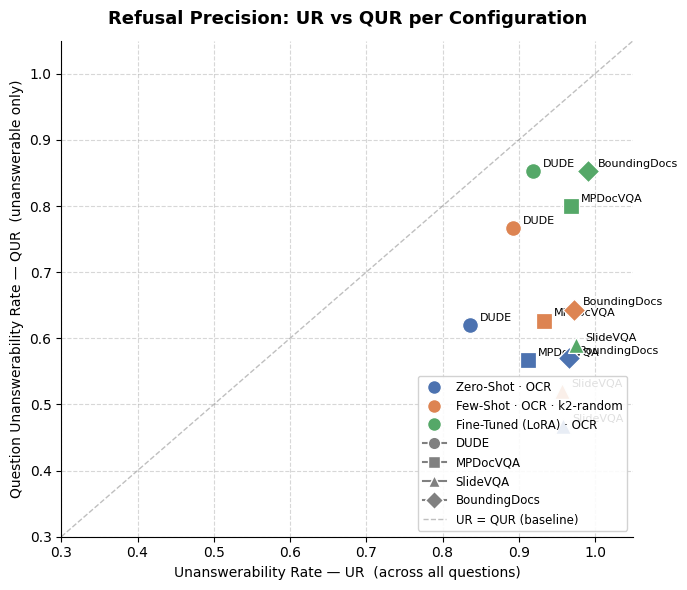

In [33]:
MARKERS = {"DUDE": "o", "MPDocVQA": "s", "SlideVQA": "^", "BDocs": "D"}

sc_records = []
for dataset in DATASETS:
    for config in CONFIGS:
        s_ur  = load_csv(dataset, config, "UR.csv")
        s_qur = load_csv(dataset, config, "QUR.csv")
        if s_ur is None or s_qur is None:
            continue
        sc_records.append({
            "dataset": dataset, "config": config,
            "UR":  s_ur.get("UR",  np.nan),
            "QUR": s_qur.get("QUR", np.nan),
        })
sc_df = pd.DataFrame(sc_records)

fig, ax = plt.subplots(figsize=(7, 6))

for config in CONFIGS:
    for dataset in DATASETS:
        row = sc_df[(sc_df.config == config) & (sc_df.dataset == dataset)]
        if row.empty:
            continue
        ur_val  = row["UR"].values[0]
        qur_val = row["QUR"].values[0]
        ax.scatter(ur_val, qur_val,
                   color=COLORS[config], marker=MARKERS[dataset],
                   s=130, zorder=5, edgecolors="white", linewidths=0.9)
        ax.annotate(DATASET_LABELS[dataset],
                    (ur_val, qur_val),
                    textcoords="offset points", xytext=(7, 3), fontsize=8)

# UR = QUR diagonal: a model that assigns equal probability of refusal to
# answerable and unanswerable questions would fall on this line
lims = [0.3, 1.05]
ax.plot(lims, lims, color="grey", linestyle="--", linewidth=1,
        alpha=0.5, label="UR = QUR (no discrimination)")
ax.set_xlim(0.3, 1.05)
ax.set_ylim(0.3, 1.05)
ax.set_xlabel("Unanswerability Rate — UR  (across all questions)", fontsize=10)
ax.set_ylabel("Question Unanswerability Rate — QUR  (unanswerable only)", fontsize=10)
ax.set_title("Refusal Precision: UR vs QUR per Configuration",
             fontsize=13, fontweight="bold", pad=12)

config_handles  = [Line2D([0], [0], marker="o", color="w",
                           markerfacecolor=COLORS[c], markersize=10,
                           label=CONFIG_LABELS[c]) for c in CONFIGS]
dataset_handles = [Line2D([0], [0], marker=MARKERS[d], color="grey",
                           markersize=9, markeredgecolor="white",
                           label=DATASET_LABELS[d]) for d in DATASETS]
diag_handle = Line2D([0], [0], color="grey", linestyle="--", linewidth=1,
                      alpha=0.5, label="UR = QUR (baseline)")
ax.legend(handles=config_handles + dataset_handles + [diag_handle],
          fontsize=8.5, loc="lower right", framealpha=0.88)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot5b_ur_vs_qur_scatter.pdf"), bbox_inches="tight")
plt.show()

### Plot 5c — Refusal Collapse: QUR vs FRR (Fine-Tuned Model)

A high QUR alone can be misleading — a model that refuses every question achieves QUR=1.  
This plot pairs QUR (correct refusal on unanswerable questions, ↑ better) with FRR  
(false refusal on answerable questions, ↓ better) to expose refusal collapse.

In [34]:
# Find the fine-tuned config slug(s) present in the run.
FT_CONFIGS = [c for c in CONFIGS if c.startswith("finetuned")]
FT_CONFIG  = FT_CONFIGS[0] if FT_CONFIGS else None

frr_records = []
if FT_CONFIG:
    for dataset in DATASETS:
        s_frr = load_csv(dataset, FT_CONFIG, "FRR.csv")
        s_qur = load_csv(dataset, FT_CONFIG, "QUR.csv")
        if s_frr is None or s_qur is None:
            continue
        has_c3 = s_qur.get("QUR_C3", 0.0) != 0.0
        frr_records.append({
            "dataset": dataset,
            "QUR": s_qur.get("QUR", np.nan), "QUR_C1": s_qur.get("QUR_C1", np.nan),
            "QUR_C2": s_qur.get("QUR_C2", np.nan),
            "QUR_C3": s_qur.get("QUR_C3", np.nan) if has_c3 else np.nan,
            "FRR": s_frr.get("FRR", np.nan), "FRR_C1": s_frr.get("FRR_C1", np.nan),
            "FRR_C2": s_frr.get("FRR_C2", np.nan),
            "FRR_C3": s_frr.get("FRR_C3", np.nan) if has_c3 else np.nan,
        })
frr_df = pd.DataFrame(frr_records).set_index("dataset") if frr_records else pd.DataFrame()
frr_df


,QUR,QUR_C1,QUR_C2,QUR_C3,FRR,FRR_C1,FRR_C2,FRR_C3
dataset,,,,,,,,
DUDE,0.853333,0.830275,0.918919,0.875000,0.29,0.334862,0.189189,0.0
MPDocVQA,0.800000,0.752252,0.925373,1.000000,0.22,0.261261,0.119403,0.0
SlideVQA,0.590000,0.512953,0.739130,0.710526,0.06,0.082902,0.028986,0.0
BDocs,0.853333,0.825726,0.966102,NaN,0.30,0.319502,0.220339,NaN


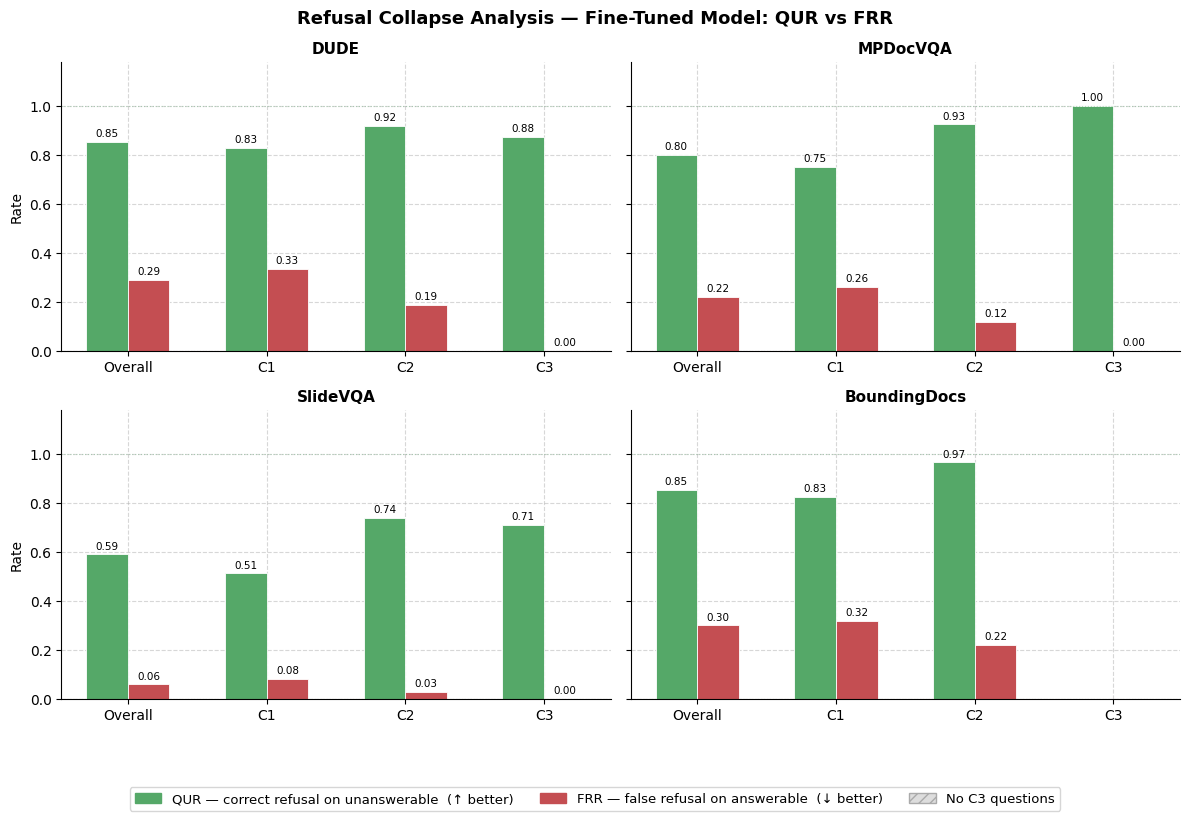

In [35]:
FT_COLOR  = "#55A868"   # fine-tuned config color
FRR_COLOR = "#C44E52"
SLOTS = [
    ("Overall", "QUR",    "FRR"),
    ("C1",      "QUR_C1", "FRR_C1"),
    ("C2",      "QUR_C2", "FRR_C2"),
    ("C3",      "QUR_C3", "FRR_C3"),
]
SLOT_LABELS = [s[0] for s in SLOTS]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()
bar_w = 0.3
x = np.arange(len(SLOTS))

for idx, dataset in enumerate(DATASETS):
    ax = axes[idx]
    if dataset not in frr_df.index:
        ax.set_visible(False)
        continue

    row = frr_df.loc[dataset]
    qur_vals = [row[s[1]] for s in SLOTS]
    frr_vals = [row[s[2]] for s in SLOTS]
    qur_plot = [v if not np.isnan(v) else 0 for v in qur_vals]
    frr_plot = [v if not np.isnan(v) else 0 for v in frr_vals]

    bars_q = ax.bar(x - bar_w / 2, qur_plot, width=bar_w,
                    color=FT_COLOR, edgecolor="white", linewidth=0.6)
    bars_f = ax.bar(x + bar_w / 2, frr_plot, width=bar_w,
                    color=FRR_COLOR, edgecolor="white", linewidth=0.6)

    for bars, vals in [(bars_q, qur_vals), (bars_f, frr_vals)]:
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.012,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=7.5)
            else:
                bar.set_hatch("///")
                bar.set_facecolor("#dddddd")
                bar.set_edgecolor("#aaaaaa")

    # Ideal reference lines
    ax.axhline(1.0, color=FT_COLOR, linestyle=":", linewidth=0.8, alpha=0.35)
    ax.axhline(0.0, color=FRR_COLOR,           linestyle=":", linewidth=0.8, alpha=0.35)

    ax.set_xticks(x)
    ax.set_xticklabels(SLOT_LABELS, fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_title(DATASET_LABELS[dataset], fontsize=11, fontweight="bold")
    if idx % 2 == 0:
        ax.set_ylabel("Rate", fontsize=10)

handles = [
    mpatches.Patch(color=FT_COLOR, label="QUR — correct refusal on unanswerable  (↑ better)"),
    mpatches.Patch(color=FRR_COLOR,           label="FRR — false refusal on answerable  (↓ better)"),
    mpatches.Patch(facecolor="#dddddd", edgecolor="#aaaaaa", hatch="///", label="No C3 questions"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9.5,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Refusal Collapse Analysis — Fine-Tuned Model: QUR vs FRR",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "plot5c_refusal_collapse.pdf"), bbox_inches="tight")
plt.show()

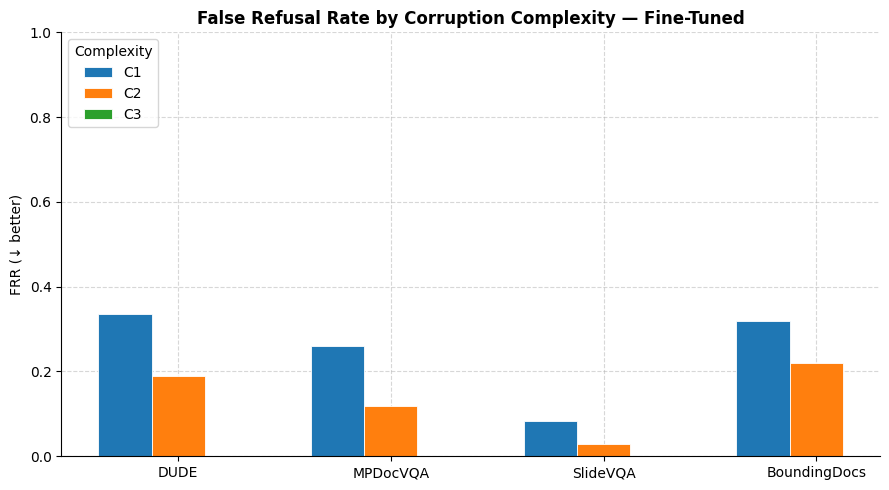

In [37]:
### Plot 5d — FRR by Complexity (is refusal level-dependent, or flat = collapse?)
if not frr_df.empty:
    COMP = [("FRR_C1", "C1"), ("FRR_C2", "C2"), ("FRR_C3", "C3")]
    x = np.arange(len(frr_df.index)); w = 0.25
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (col, lab) in enumerate(COMP):
        ax.bar(x + (i - 1) * w, frr_df[col].values, width=w, label=lab,
               edgecolor="white", linewidth=0.6)
    ax.set_xticks(x); ax.set_xticklabels([DATASET_LABELS[d] for d in frr_df.index])
    ax.set_ylabel("FRR (↓ better)"); ax.set_ylim(0, 1)
    ax.set_title("False Refusal Rate by Corruption Complexity — Fine-Tuned", fontweight="bold")
    ax.legend(title="Complexity")
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "plot5d_frr_by_complexity.pdf"), bbox_inches="tight"); plt.show()


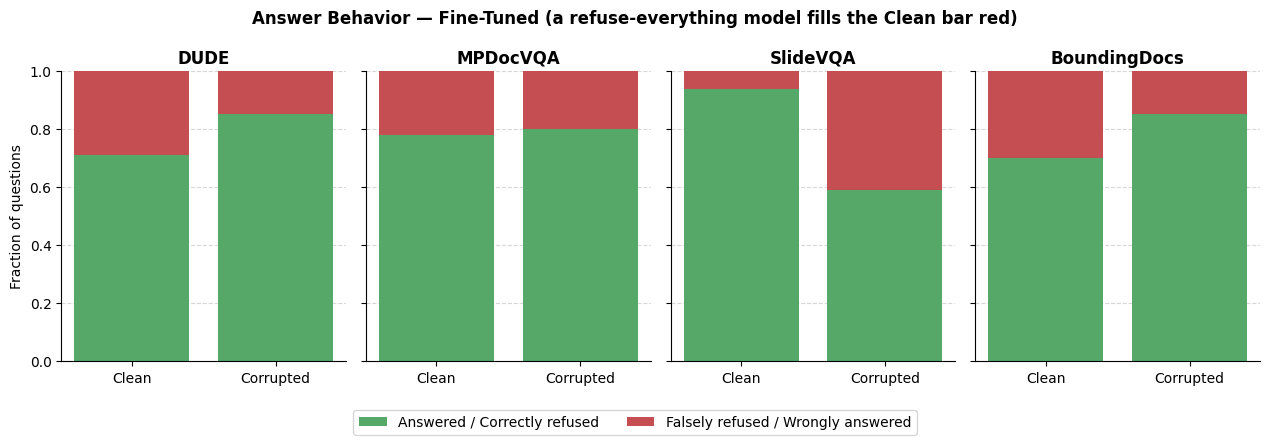

In [38]:
### Plot 5e — Answer Behavior: refuse-everything check
if not frr_df.empty:
    fig, axes = plt.subplots(1, len(frr_df.index), figsize=(3.2 * len(frr_df.index), 4.2), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, dataset in zip(axes, frr_df.index):
        r = frr_df.loc[dataset]
        clean_ans, clean_ref = 1 - r["FRR"], r["FRR"]
        corr_ref, corr_ans  = r["QUR"], 1 - r["QUR"]
        ax.bar(["Clean", "Corrupted"], [clean_ans, corr_ref], color="#55A868", label="Answered / Correctly refused")
        ax.bar(["Clean", "Corrupted"], [clean_ref, corr_ans], bottom=[clean_ans, corr_ref],
               color="#C44E52", label="Falsely refused / Wrongly answered")
        ax.set_ylim(0, 1); ax.set_title(DATASET_LABELS[dataset], fontweight="bold")
    axes[0].set_ylabel("Fraction of questions")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle("Answer Behavior — Fine-Tuned (a refuse-everything model fills the Clean bar red)", fontweight="bold")
    plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.savefig(os.path.join(OUTPUT_DIR, "plot5e_answer_behavior.pdf"), bbox_inches="tight"); plt.show()


[MISSING] /home/amartinelli/VRD-UQA/artifacts/presentations/gemma4_all_val_300/DUDE/zeroshot_ocr/metrics/FRR.csv
[MISSING] /home/amartinelli/VRD-UQA/artifacts/presentations/gemma4_all_val_300/MPDocVQA/zeroshot_ocr/metrics/FRR.csv
[MISSING] /home/amartinelli/VRD-UQA/artifacts/presentations/gemma4_all_val_300/SlideVQA/zeroshot_ocr/metrics/FRR.csv
[MISSING] /home/amartinelli/VRD-UQA/artifacts/presentations/gemma4_all_val_300/BDocs/zeroshot_ocr/metrics/FRR.csv


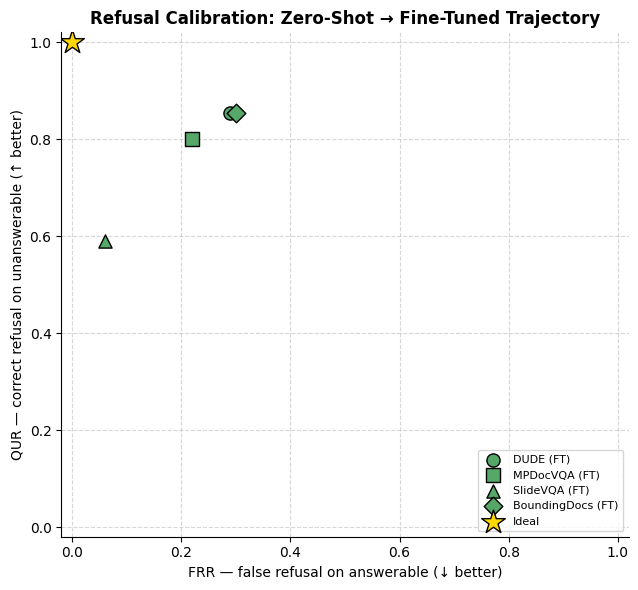

In [39]:
### Plot 5f — QUR vs FRR with zero-shot -> fine-tuned trajectory
ZS_CONFIG_SLUG = next((c for c in CONFIGS if c.startswith("zeroshot")), None)
if FT_CONFIG:
    fig, ax = plt.subplots(figsize=(6.5, 6))
    MARKERS = {"DUDE": "o", "MPDocVQA": "s", "SlideVQA": "^", "BDocs": "D"}
    for dataset in DATASETS:
        ft_q, ft_f = load_csv(dataset, FT_CONFIG, "QUR.csv"), load_csv(dataset, FT_CONFIG, "FRR.csv")
        if ft_q is None or ft_f is None:
            continue
        ax.scatter(ft_f["FRR"], ft_q["QUR"], marker=MARKERS.get(dataset, "o"),
                   s=90, color="#55A868", edgecolor="black", zorder=3, label=f"{DATASET_LABELS[dataset]} (FT)")
        if ZS_CONFIG_SLUG:
            zq, zf = load_csv(dataset, ZS_CONFIG_SLUG, "QUR.csv"), load_csv(dataset, ZS_CONFIG_SLUG, "FRR.csv")
            if zq is not None and zf is not None:
                ax.annotate("", xy=(ft_f["FRR"], ft_q["QUR"]), xytext=(zf["FRR"], zq["QUR"]),
                            arrowprops=dict(arrowstyle="->", color="#999999", lw=1.3))
                ax.scatter(zf["FRR"], zq["QUR"], marker=MARKERS.get(dataset, "o"),
                           s=70, facecolor="white", edgecolor="#4C72B0", zorder=3)
    ax.scatter([0], [1], marker="*", s=320, color="gold", edgecolor="black", zorder=4, label="Ideal")
    ax.set_xlabel("FRR — false refusal on answerable (↓ better)")
    ax.set_ylabel("QUR — correct refusal on unanswerable (↑ better)")
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_title("Refusal Calibration: Zero-Shot → Fine-Tuned Trajectory", fontweight="bold")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "plot5f_qur_frr_trajectory.pdf"), bbox_inches="tight"); plt.show()


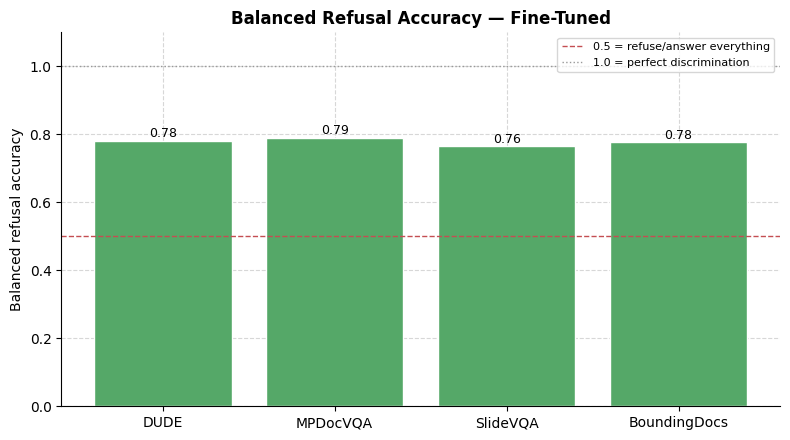

In [40]:
### Plot 5g — Balanced Refusal Accuracy = (QUR + (1 - FRR)) / 2
if not frr_df.empty:
    bra = ((frr_df["QUR"] + (1 - frr_df["FRR"])) / 2).reindex(DATASETS).dropna()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar([DATASET_LABELS[d] for d in bra.index], bra.values,
                  color="#55A868", edgecolor="white")
    for b, v in zip(bars, bra.values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
    ax.axhline(0.5, color="#C44E52", linestyle="--", lw=1, label="0.5 = refuse/answer everything")
    ax.axhline(1.0, color="#999999", linestyle=":", lw=1, label="1.0 = perfect discrimination")
    ax.set_ylim(0, 1.1); ax.set_ylabel("Balanced refusal accuracy")
    ax.set_title("Balanced Refusal Accuracy — Fine-Tuned", fontweight="bold")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "plot5g_balanced_refusal_accuracy.pdf"), bbox_inches="tight"); plt.show()
